# Clustering Analysis
Grouping individuals based on their characteristics.

## 1. Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('datasets/Lab Assignment Module 6_Even NIM.csv')

# Explore dataset
print("First 5 data points:")
display(df.head())
print("\nData type information:")
df.info()

# Check missing values
print("\nMissing values before handling:")
print(df.isna().sum())

# Handle missing values (mean for num, mode for cat)
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

# Encode categorical variables
categorical_cols = df.select_dtypes(exclude=[np.number]).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Normalize numerical features
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print("\nData after preprocessing:")
display(df_scaled.head())

First 5 data points:


,ID,Age,Gender,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Average Glucose Level,BMI,...,Dietary Habits,Alcohol Consumption,Chronic Stress,Sleep Hours,Family History of Stroke,Education Level,Income Level,Stroke Risk Score,Region,Stroke Occurrence
0,1,78,Female,0,0,1,Private,Rural,267.30,36.2,...,Non-Vegetarian,0,0,11,0,Tertiary,Middle,88,South,0
1,2,60,Female,0,0,0,Private,Rural,207.24,19.8,...,Vegetarian,0,0,9,0,Secondary,High,56,East,0
2,3,69,Male,0,0,0,Private,Urban,161.30,34.5,...,Mixed,1,0,3,0,Secondary,High,63,North,1
3,4,43,Male,0,0,1,Never Worked,Urban,247.49,48.8,...,Mixed,0,1,4,0,Tertiary,Middle,93,South,0
4,5,30,Female,0,0,1,Government,Urban,116.57,31.3,...,Mixed,0,1,9,0,Secondary,High,99,West,0



Data type information:
<class 'pandas.DataFrame'>
RangeIndex: 172000 entries, 0 to 171999
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        172000 non-null  int64  
 1   Age                       172000 non-null  int64  
 2   Gender                    172000 non-null  str    
 3   Hypertension              172000 non-null  int64  
 4   Heart Disease             172000 non-null  int64  
 5   Ever Married              172000 non-null  int64  
 6   Work Type                 172000 non-null  str    
 7   Residence Type            172000 non-null  str    
 8   Average Glucose Level     172000 non-null  float64
 9   BMI                       172000 non-null  float64
 10  Smoking Status            172000 non-null  str    
 11  Physical Activity         172000 non-null  str    
 12  Dietary Habits            172000 non-null  str    
 13  Alcohol Consumption       17200

,Age,Gender,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Average Glucose Level,BMI,Smoking Status,...,Dietary Habits,Alcohol Consumption,Chronic Stress,Sleep Hours,Family History of Stroke,Education Level,Income Level,Stroke Risk Score,Region,Stroke Occurrence
0,1.138254,-0.980922,-0.420304,-0.33385,1.524022,0.333043,-1.000919,1.242103,0.534747,-1.325999,...,-0.145712,-0.500263,-0.577350,1.217242,-0.418349,1.444979,1.287280,1.293164,0.449653,-0.332212
1,0.284214,-0.980922,-0.420304,-0.33385,-0.656158,0.333043,-1.000919,0.336411,-0.882672,-0.119123,...,1.283486,-0.500263,-0.577350,0.521631,-0.418349,0.333039,-1.571846,0.186149,-1.339473,-0.332212
2,0.711234,0.769634,-0.420304,-0.33385,-0.656158,0.333043,0.999082,-0.356355,0.387820,-0.119123,...,-1.574909,1.998947,-0.577350,-1.565201,-0.418349,0.333039,-1.571846,0.428308,-0.444910,3.010122
3,-0.522380,0.769634,-0.420304,-0.33385,1.524022,-0.499879,0.999082,0.943373,1.623740,-0.119123,...,-1.574909,-0.500263,1.732051,-1.217396,-0.418349,1.444979,1.287280,1.466135,0.449653,-0.332212
4,-1.139186,-0.980922,-0.420304,-0.33385,1.524022,-1.332801,0.999082,-1.030874,0.111250,-1.325999,...,-1.574909,-0.500263,1.732051,0.521631,-0.418349,0.333039,-1.571846,1.673700,1.344216,-0.332212


## 2. K-Means Clustering

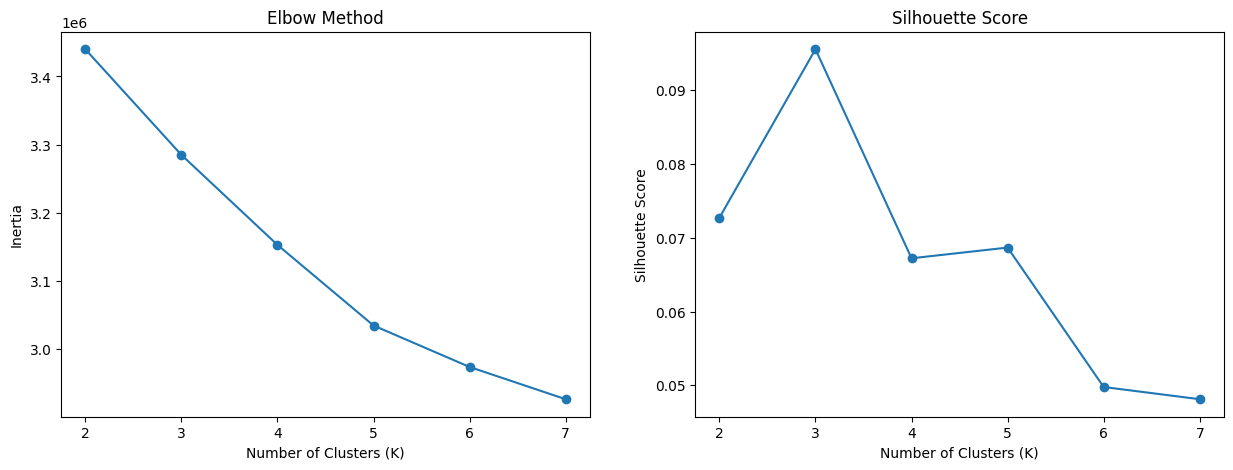

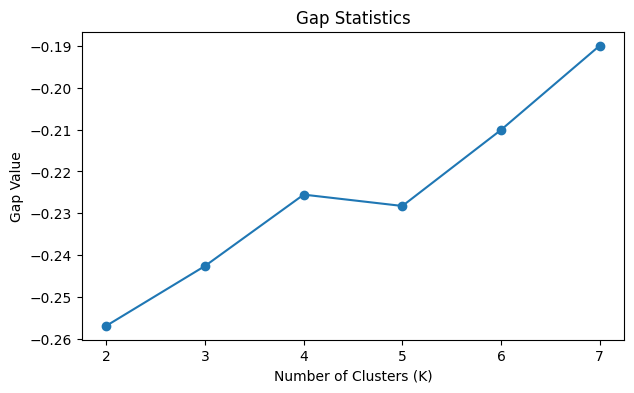

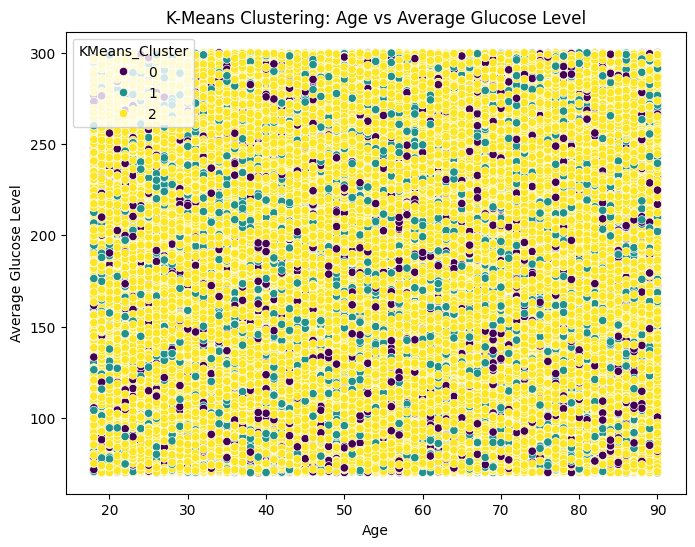

Interpretation of K-Means Cluster Centroids (Mean values):


,Age,Average Glucose Level,BMI,Hypertension,Heart Disease
KMeans_Cluster,,,,,
0,54.051825,184.973894,29.970005,0.147520,0.101603
1,53.831297,184.156363,29.957534,0.147431,0.099168
2,54.035639,185.061422,30.028026,0.150946,0.100302


The results above help us understand the distinct profiles of individuals within each cluster, highlighting the patterns related to their glucose level, BMI, and age against heart disease risk.


In [2]:
inertia = []
sil_scores = []
K_range = range(2, 8)

# Use a sample for silhouette & gap statistic to speed up computation on 170k+ rows
sample_size = 5000
df_sampled = df_scaled.sample(n=sample_size, random_state=42)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled) # Fit on full data
    inertia.append(kmeans.inertia_)
    # Calculate silhouette score solely based on the sample to prevent memory/time blowup
    sil_scores.append(silhouette_score(df_scaled, kmeans.labels_, sample_size=sample_size, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(K_range, inertia, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='o')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
plt.show()

# Gap Statistic (Re-added and calculated on sample)
def calculate_gap_statistic(data, n_refs=3, max_clusters=7):
    gaps = np.zeros(max_clusters - 1)
    mins = data.min(axis=0)
    maxs = data.max(axis=0)
    for k in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(data)
        actual_inertia = kmeans.inertia_
        ref_inertias = np.zeros(n_refs)
        for i in range(n_refs):
            random_data = np.random.uniform(mins, maxs, size=data.shape)
            km_ref = KMeans(n_clusters=k, random_state=42, n_init=10).fit(random_data)
            ref_inertias[i] = km_ref.inertia_
        expected_log_inertia = np.mean(np.log(ref_inertias))
        gaps[k-2] = expected_log_inertia - np.log(actual_inertia)
    return gaps

gaps = calculate_gap_statistic(df_sampled.values)
plt.figure(figsize=(7, 4))
plt.plot(range(2, 8), gaps, marker='o')
plt.title('Gap Statistics')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Gap Value')
plt.show()

# Apply optimal K-Means to the dataset
optimal_k = 3 # Can be adjusted based on the charts above
kmeans_opt = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_opt.fit_predict(df_scaled)
df_scaled['KMeans_Cluster'] = df['KMeans_Cluster']

# Visualize clustering results
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Age'], y=df['Average Glucose Level'], hue=df['KMeans_Cluster'], palette='viridis')
plt.title('K-Means Clustering: Age vs Average Glucose Level')
plt.show()

# Interpret results
print("Interpretation of K-Means Cluster Centroids (Mean values):")
display(df.groupby('KMeans_Cluster').mean()[['Age', 'Average Glucose Level', 'BMI', 'Hypertension', 'Heart Disease']])
print("The results above help us understand the distinct profiles of individuals within each cluster, highlighting the patterns related to their glucose level, BMI, and age against heart disease risk.")

## 3. DBSCAN Clustering

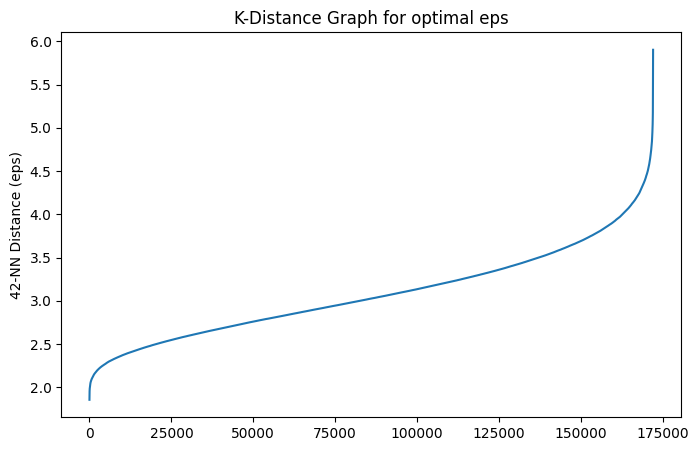

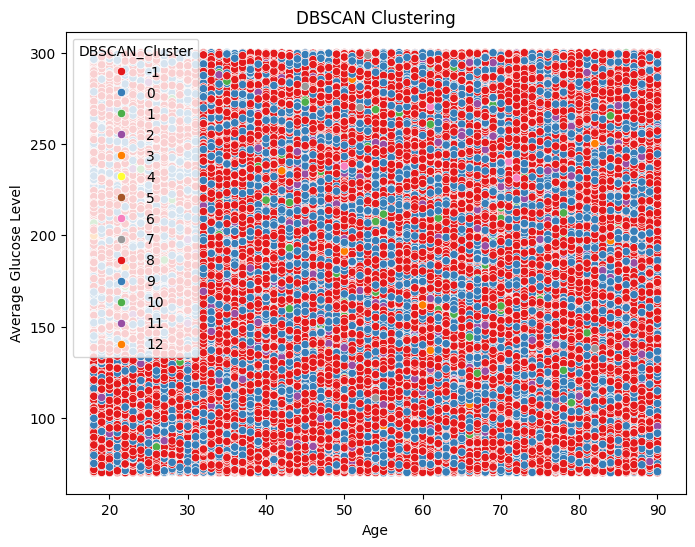

DBSCAN Clusters (-1 = noise):
DBSCAN_Cluster
-1     107455
 0      57869
 2       4022
 1       1616
 3        483
 7        206
 6         59
 4         44
 9         43
 8         43
 5         42
 11        42
 12        41
 10        35
Name: count, dtype: int64


In [3]:
data_for_dbscan = df_scaled.drop('KMeans_Cluster', axis=1)

# Using double the number of dimensions/features as min_samples (systematic approach)
min_samples = 2 * (data_for_dbscan.shape[1]) 

# Warning: NearestNeighbors and DBSCAN will take a lot of RAM/Time on 172k points
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(data_for_dbscan)
distances, indices = neighbors_fit.kneighbors(data_for_dbscan)
distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title('K-Distance Graph for optimal eps')
plt.ylabel(f'{min_samples}-NN Distance (eps)')
plt.show()

# Setting eps based on typical 'elbow' observed from distance graph
eps_val = 2.5 
dbscan = DBSCAN(eps=eps_val, min_samples=min_samples)

# Apply DBSCAN to the full dataset
df['DBSCAN_Cluster'] = dbscan.fit_predict(data_for_dbscan)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Age'], y=df['Average Glucose Level'], hue=df['DBSCAN_Cluster'], palette='Set1')
plt.title('DBSCAN Clustering')
plt.show()

print("DBSCAN Clusters (-1 = noise):")
print(df['DBSCAN_Cluster'].value_counts())

### Comparison
**K-Means:** Simple, forces spherical clusters. Disadvantage: Requires specifying K, sensitive to outliers.
**DBSCAN:** Discovers naturally shaped clusters and identifies outliers (-1). Disadvantage: Sensitive to parameters and dimensional density variations.